# P1 signal audit

In [ ]:
# Check the if the dataset is available

In [6]:
from pathlib import Path
import numpy as np
from PIL import Image

RESOURCE_DIR_KIRMIZI = Path("dataset/Pistachio_Image_Dataset/Pistachio_Image_Dataset/Kirmizi_Pistachio")
RESOURCE_DIR_SIIRT    = Path("dataset/Pistachio_Image_Dataset/Pistachio_Image_Dataset/Siirt_Pistachio")

for name, folder in [("Kirmizi", RESOURCE_DIR_KIRMIZI), ("Siirt", RESOURCE_DIR_SIIRT)]:
    if folder.is_dir():
        print(f"OK   {name}: {folder.resolve()}")
    else:
        print(f"MISS {name}: {folder.resolve()}")



# Cap how many images to load per class
LIMIT = 5 # None = load everyting

records = []
for name, folder in [("Kirmizi", RESOURCE_DIR_KIRMIZI), ("Siirt", RESOURCE_DIR_SIIRT)]:
    count = 0
    for path in sorted(folder.rglob("*")):
        if path.suffix.lower() not in {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}:
            continue
        if LIMIT is not None and count >= LIMIT:
            break
        with Image.open(path) as im:
            arr = np.asarray(im.convert("RGB"))
        records.append({"class": name, "path": path, "arr": arr})
        count += 1

print(f"Loaded {len(records)} images (LIMIT={LIMIT} per class)")

OK   Kirmizi: /home/vibe/skole/IDIG4120/p0/dataset/Pistachio_Image_Dataset/Pistachio_Image_Dataset/Kirmizi_Pistachio
OK   Siirt: /home/vibe/skole/IDIG4120/p0/dataset/Pistachio_Image_Dataset/Pistachio_Image_Dataset/Siirt_Pistachio
Loaded 10 images (LIMIT=5 per class)


# Format, array shape, data type, units, range and byte size

In [13]:
# 1. Format (from magic bytes, not the extension)
def detect_format(path):
    with open(path, "rb") as fh:
        head = fh.read(8)
    if head.startswith(b"\xff\xd8\xff"):
        return "JPEG"
    if head.startswith(b"\x89PNG"):
        return "PNG"
    return "other"

formats = {r["class"]: {} for r in records}
for r in records:
    fmt = detect_format(r["path"])
    formats[r["class"]][fmt] = formats[r["class"]].get(fmt, 0) + 1
print("1. Format:", formats)

# 2. Array shape
shapes = {r["arr"].shape for r in records}
print("2. Per-image (H, W, C):", shapes)

# 3. Data type
print("3. Data type:", records[0]["arr"].dtype)

# 4. Units
stacked = np.stack([r["arr"] for r in records])
lo, hi = int(stacked.min()), int(stacked.max())
is_8bit = lo >= 0 and hi <= 255
print(f"4. Units: pixel values are 8-bit intensity levels 0-255")
print(f"   Verified: observed range {lo}-{hi} -> within 0-255: {is_8bit}")

# 5. Range (per channel, across the loaded subset)
stacked = np.stack([r["arr"] for r in records])
for i, ch in enumerate("RGB"):
    print(f"5. {ch}: min={stacked[..., i].min()} max={stacked[..., i].max()}")

# 6. Byte size (per image)
for r in records[:1]:
    disk = r["path"].stat().st_size
    mem = r["arr"].nbytes
    print(f"6. {r['class']:8s} {r['path'].name:20s} on disk: {disk:>8} B | in memory: {mem:>8} B")

1. Format: {'Kirmizi': {'JPEG': 5}, 'Siirt': {'JPEG': 5}}
2. Per-image (H, W, C): {(600, 600, 3)}
3. Data type: uint8
4. Units: pixel values are 8-bit intensity levels 0-255
   Verified: observed range 0-255 -> within 0-255: True
5. R: min=0 max=255
5. G: min=0 max=255
5. B: min=0 max=255
6. Kirmizi  kirmizi (1).jpg      on disk:    22307 B | in memory:  1080000 B


# Sampling rate or spacing

In [ ]:
# Take one image instance and flatten it to a 1D signal (raster scan, row-major).
img = records[0]["arr"]          # (H, W, C)
signal = img.flatten()           # (H*W*C,) 1D sequence
print(f"Image shape: {img.shape}")
print(f"Flattened 1D signal length: {len(signal)} samples")

# Sampling rate / spacing
# The 1D signal is sampled once per pixel along the scan. The "sampling rate"
# in physical units (samples per mm) requires calibration that the dataset
# does not provide.
print(f"- Sampling: 1 sample per pixel along the raster scan.")
print(f"- Spatial sampling grid: {img.shape[1]} x {img.shape[0]} px (W x H).")

# Try to read DPI metadata -> convert to px/mm if present.
with Image.open(records[0]["path"]) as im:
    dpi = im.info.get("dpi")

if dpi:
    px_per_mm = dpi[0] / 25.4
    print(f"- DPI metadata present: {dpi[0]:.0f} x {dpi[1]:.0f} "
          f"-> ~{px_per_mm:.2f} px/mm.")
else:
    print("- DPI metadata: NOT AVAILABLE / UNKNOWN (not stored in the file).")

Image shape: (600, 600, 3)
Flattened 1D signal length: 1080000 samples
- Sampling: 1 sample per pixel along the raster scan.
- Spatial sampling grid: 600 x 600 px (W x H).
- DPI metadata present: 96 x 96 -> ~3.78 px/mm.


# One time or spatial view and one frequency view, both with labelled axes.

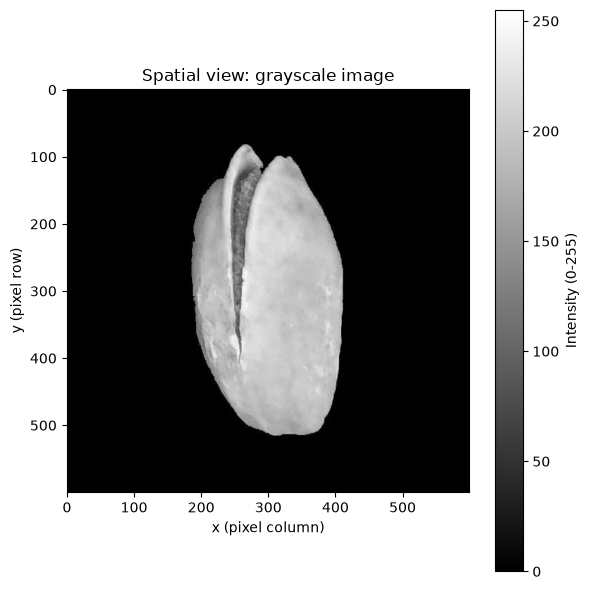

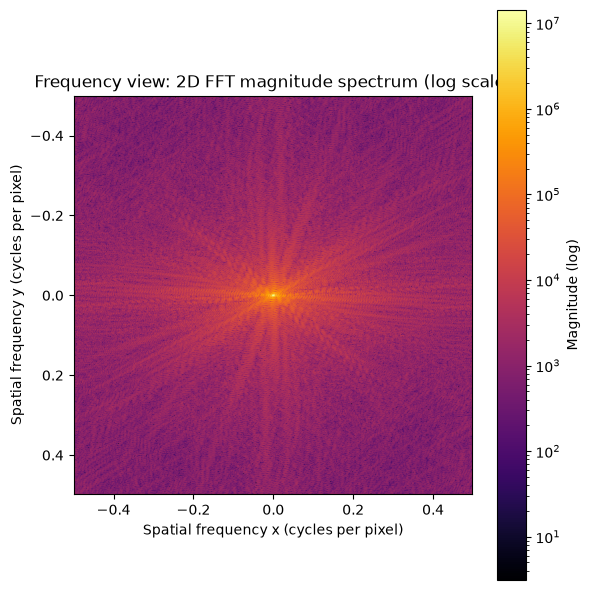

In [36]:
import numpy as np
import matplotlib.pyplot as plt

# Convert the image to grayscale (luminance) for a single 2D signal.
gray = np.mean(records[0]["arr"], axis=2)   # (H, W) float, average of RGB
H, W = gray.shape

# --- Spatial view (the grayscale image itself) ---
fig, ax = plt.subplots(figsize=(6, 6))
im = ax.imshow(gray, cmap="gray", vmin=0, vmax=255)
ax.set_xlabel("x (pixel column)")
ax.set_ylabel("y (pixel row)")
ax.set_title("Spatial view: grayscale image")
plt.colorbar(im, ax=ax, label="Intensity (0-255)")
plt.tight_layout()
plt.show()

# --- Frequency view (2D FFT magnitude spectrum) ---
# Shift so DC is at the centre. Axes are in cycles per pixel (normalised),
# since the physical sampling rate is unknown.
spectrum = np.abs(np.fft.fftshift(np.fft.fft2(gray)))
freq_x = np.fft.fftshift(np.fft.fftfreq(W, d=1.0))   # cycles/pixel, x
freq_y = np.fft.fftshift(np.fft.fftfreq(H, d=1.0))   # cycles/pixel, y

fig2, ax2 = plt.subplots(figsize=(6, 6))
im2 = ax2.imshow(spectrum, extent=[freq_x[0], freq_x[-1], freq_y[-1], freq_y[0]],
                 cmap="inferno", norm="log")
ax2.set_xlabel("Spatial frequency x (cycles per pixel)")
ax2.set_ylabel("Spatial frequency y (cycles per pixel)")
ax2.set_title("Frequency view: 2D FFT magnitude spectrum (log scale)")
plt.colorbar(im2, ax=ax2, label="Magnitude (log)")
plt.tight_layout()
plt.show()


# One transform or filtering experiment, with the prediction you made before running it.

prediction:
We run a gaussian filter, that redueces high spatial frequencies, but overall shape and large color will be kept. 

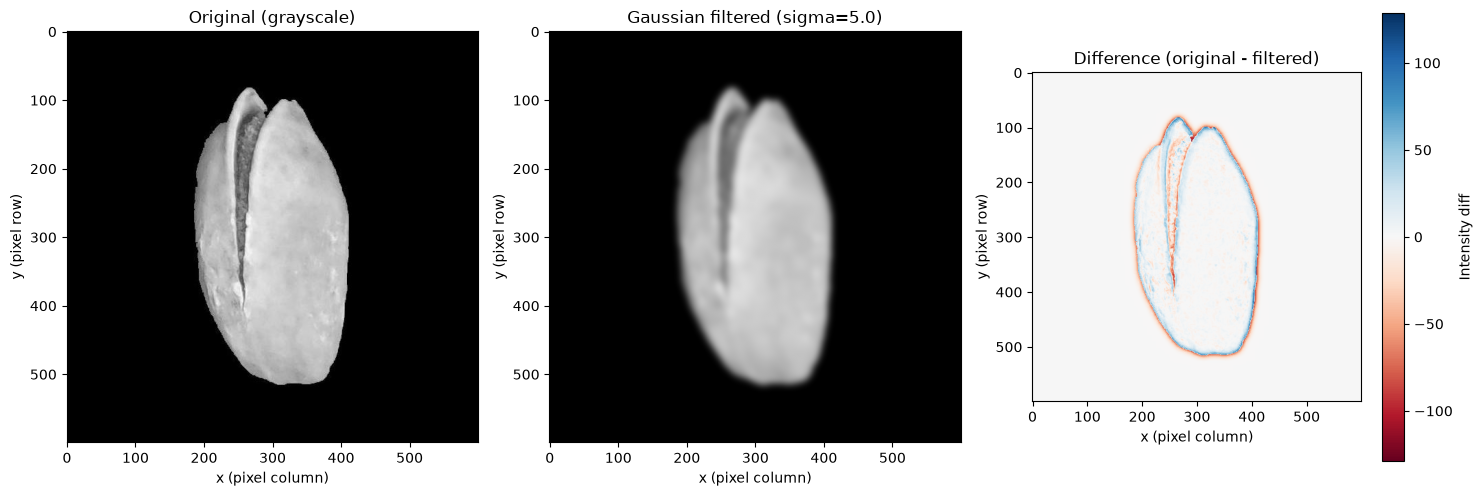

sigma=5.0: high spatial frequencies attenuated; overall shape and large-scale structure preserved (matches prediction).


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Gaussian filter experiment on one image (colour, RGB).
# Prediction (cell above): reduces high spatial frequencies; overall shape
# and large-scale structure are kept.

img = records[0]["arr"].astype(float)   # (H, W, 3) float

# Build a 1D Gaussian kernel, then convolve separably (2D = outer product).
def gaussian_kernel(sigma, size=None):
    if size is None:
        size = int(6 * sigma) | 1   # odd size covering ~3 sigma each side
    x = np.arange(size) - size // 2
    k = np.exp(-(x ** 2) / (2 * sigma ** 2))
    return k / k.sum()

def convolve1d(signal, kernel):
    return np.convolve(signal, kernel, mode="same")

def gaussian_filter2d(arr, sigma):
    k = gaussian_kernel(sigma)
    out = np.apply_along_axis(lambda r: convolve1d(r, k), axis=1, arr=arr)
    out = np.apply_along_axis(lambda c: convolve1d(c, k), axis=0, arr=out)
    return out

sigma = 5.0
# Apply the filter to each colour channel independently.
blurred = np.stack([gaussian_filter2d(img[..., c], sigma) for c in range(3)], axis=2)

# Show original vs filtered, plus the difference.
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img.astype(np.uint8))
axes[0].set_title("Original (colour)")
axes[0].set_xlabel("x (pixel column)")
axes[0].set_ylabel("y (pixel row)")

axes[1].imshow(np.clip(blurred, 0, 255).astype(np.uint8))
axes[1].set_title(f"Gaussian filtered (sigma={sigma})")
axes[1].set_xlabel("x (pixel column)")
axes[1].set_ylabel("y (pixel row)")

diff = img - blurred
imd = axes[2].imshow(np.clip(diff, 0, 255).astype(np.uint8))
axes[2].set_title("Difference (original - filtered)")
axes[2].set_xlabel("x (pixel column)")
axes[2].set_ylabel("y (pixel row)")
plt.tight_layout()
plt.show()

print(f"sigma={sigma}: high spatial frequencies attenuated; "
      f"overall shape and large-scale structure preserved (matches prediction).")